In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, mean_absolute_error

In [16]:
def clean_text_for_merge(text_series):
    """
    Standardizes text strings to prevent merge mismatches caused by
    varied whitespaces, casing, or trailing special characters.
    """
    return (text_series.astype(str)
            .str.lower()
            .str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
            .str.replace(r'\s+', ' ', regex=True)
            .str.strip())

Loading datasets
Normalizing text columns for precise alignment...
Performing multi-way inner join...
Total overlapping rows matched across all 4 models: 28109
Parsing and validating integer scores:
Calculating Comparative Performance Metrics:

               EVALUATION RESULTS (vs. KIMI)
| Model   |   SAD (Lower is Better) |   MAE (Lower is Better) |   QWK (Higher is Better) |
|:--------|------------------------:|------------------------:|-------------------------:|
| Qwen    |                   44013 |                  1.5658 |                   0.7954 |
| Mistral |                   46816 |                  1.6655 |                   0.7839 |
| Gemini  |                   45525 |                  1.6196 |                   0.7774 |

Generating and saving visualization plot...


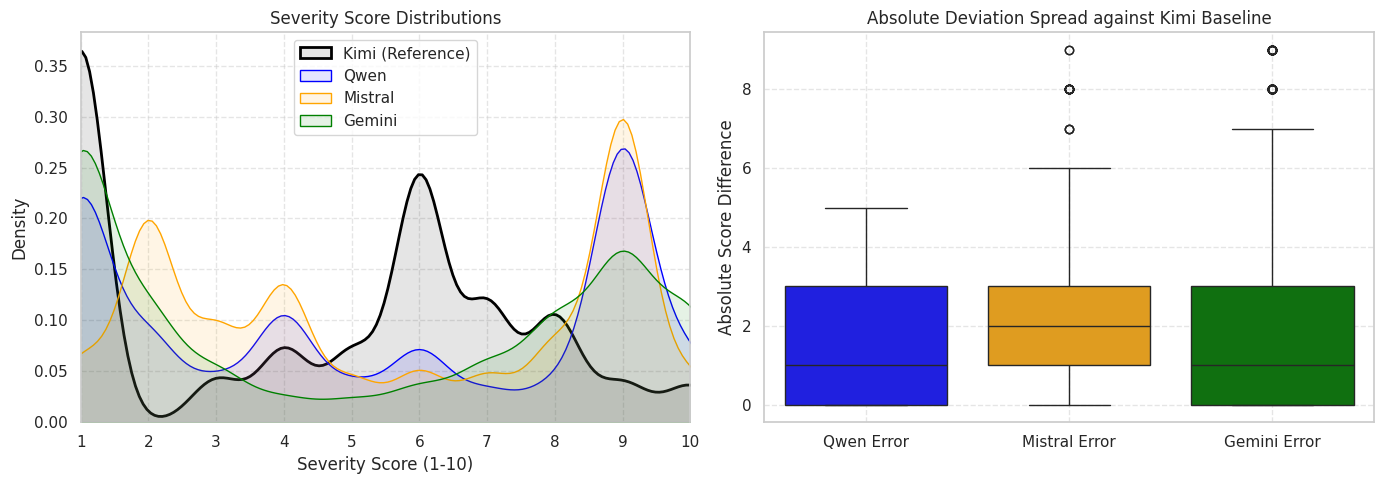

In [17]:
def main():
    print("Loading datasets")
    try:
        df_qwen = pd.read_excel("/content/NLP_qwen_labels_output.xlsx")
        df_mistral = pd.read_excel("/content/NLP_Mistral_labels_output.xlsx")
        df_gemini = pd.read_excel("/content/NLP_Gemini_labels_output.xlsx")
        df_kimi = pd.read_csv("/content/mental_health_classification_results_kimi.csv")
    except FileNotFoundError as e:
        print(f"\n[Error] File not found. Please check paths. Details: {e}")
        return

    df_qwen = df_qwen[['text', 'qwen_score']].copy()
    df_mistral = df_mistral[['text', 'mistral_score']].copy()
    df_gemini = df_gemini[['text', 'gemini_score']].copy()
    df_kimi = df_kimi[['text', 'score']].copy()
    df_kimi.rename(columns={'score': 'kimi_score'}, inplace=True)

    print("Normalizing text columns for precise alignment...")
    df_qwen['clean_text'] = clean_text_for_merge(df_qwen['text'])
    df_mistral['clean_text'] = clean_text_for_merge(df_mistral['text'])
    df_gemini['clean_text'] = clean_text_for_merge(df_gemini['text'])
    df_kimi['clean_text'] = clean_text_for_merge(df_kimi['text'])

    df_qwen.drop(columns=['text'], inplace=True)
    df_mistral.drop(columns=['text'], inplace=True)
    df_gemini.drop(columns=['text'], inplace=True)

    print("Performing multi-way inner join...")
    merged_df = df_kimi.merge(df_qwen, on='clean_text', how='inner')
    merged_df = merged_df.merge(df_mistral, on='clean_text', how='inner')
    merged_df = merged_df.merge(df_gemini, on='clean_text', how='inner')

    print(f"Total overlapping rows matched across all 4 models: {len(merged_df)}")

    print("Parsing and validating integer scores:")
    score_columns = ['kimi_score', 'qwen_score', 'mistral_score', 'gemini_score']

    for col in score_columns:
        merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

    initial_len = len(merged_df)
    merged_df.dropna(subset=score_columns, inplace=True)

    for col in score_columns:
        merged_df[col] = merged_df[col].astype(int)

    final_len = len(merged_df)
    if initial_len != final_len:
        print(f"Dropped {initial_len - final_len} rows containing invalid or non-numeric scores.")

    print("Calculating Comparative Performance Metrics:")

    models = {
        'Qwen': 'qwen_score',
        'Mistral': 'mistral_score',
        'Gemini': 'gemini_score'
    }

    results = []

    y_true = merged_df['kimi_score'].values
    rating_labels = list(range(1, 11))

    for name, col_name in models.items():
        y_pred = merged_df[col_name].values

        sad = np.sum(np.abs(y_true - y_pred))

        mae = mean_absolute_error(y_true, y_pred)

        qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic', labels=rating_labels)

        results.append({
            'Model': name,
            'SAD (Lower is Better)': sad,
            'MAE (Lower is Better)': round(mae, 4),
            'QWK (Higher is Better)': round(qwk, 4)
        })

    results_df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("               EVALUATION RESULTS (vs. KIMI)")
    print("="*60)
    print(results_df.to_markdown(index=False))
    print("="*60)

    print("\nGenerating and saving visualization plot...")
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.kdeplot(merged_df['kimi_score'], label='Kimi (Reference)', fill=True, alpha=0.1, color='black', linewidth=2)
    sns.kdeplot(merged_df['qwen_score'], label='Qwen', fill=True, alpha=0.1, color='blue')
    sns.kdeplot(merged_df['mistral_score'], label='Mistral', fill=True, alpha=0.1, color='orange')
    sns.kdeplot(merged_df['gemini_score'], label='Gemini', fill=True, alpha=0.1, color='green')
    plt.title("Severity Score Distributions")
    plt.xlabel("Severity Score (1-10)")
    plt.ylabel("Density")
    plt.xlim(1, 10)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(1, 2, 2)
    error_data = pd.DataFrame({
        'Qwen Error': np.abs(merged_df['qwen_score'] - merged_df['kimi_score']),
        'Mistral Error': np.abs(merged_df['mistral_score'] - merged_df['kimi_score']),
        'Gemini Error': np.abs(merged_df['gemini_score'] - merged_df['kimi_score'])
    })
    sns.boxplot(data=error_data, palette=['blue', 'orange', 'green'])
    plt.title("Absolute Deviation Spread against Kimi Baseline")
    plt.ylabel("Absolute Score Difference")
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()

if __name__ == "__main__":
    main()